#  Classes 2 & 3 – Business Intelligence
## Hands-On Activity: EDA, Data Cleaning & Transformation
**Context: Hotel Reception Operations**
**Estimated time: 50 minutes**

---

In this activity you will work through a **realistic, messy Hotel Reservations dataset** and apply the concepts from Classes 2 and 3:**texto en negrita**

## Setup – Install & Import Libraries

In [2]:
# YOUR CODE HERE
# Install and import: pandas, numpy, matplotlib, seaborn, sklearn

import pandas as pd
import numpy  as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn as sk 


## Load the Dataset

We will generate a synthetic **Hotel Reservations dataset** with intentional data-quality issues for you to fix.

The dataset represents records from the **front desk system** of a mid-size hotel. Each row is one reservation.

In [3]:
df = pd.read_csv("HotelReception_dataset.csv")
df.head()

,reservation_id,nights,room_type,room_rate,guests,lead_days,booking_channel,meal_plan,satisfaction,cancelled
0,RES-0001,7,Suite,103.42,4,57.0,walk-in,NaN,Very Dissatisfied,0
1,RES-0002,4,SUITE,NaN,2,25.0,Walk-in,NaN,Neutral,0
2,RES-0003,13,SUITE,84.28,2,225.0,ONLINE,NaN,Very Dissatisfied,0
3,RES-0004,11,Twin,106.61,2,284.0,Online,NaN,Neutral,0
4,RES-0005,8,Double,NaN,4,NaN,Travel Agency,NaN,Very Satisfied,0


---

## 🩺 Section 1 – Data Profiling (Health Check)

> *"Before modelling, understand what you have."*

### 1.1 Basic Information
Get column types and non-null counts, and a statistical description of numerical variables.

In [9]:
# YOUR CODE HERE
# Show column types, non-null counts
df = pd.read_csv("HotelReception_dataset.csv")
df.head()

,reservation_id,nights,room_type,room_rate,guests,lead_days,booking_channel,meal_plan,satisfaction,cancelled
0,RES-0001,7,Suite,103.42,4,57.0,walk-in,NaN,Very Dissatisfied,0
1,RES-0002,4,SUITE,NaN,2,25.0,Walk-in,NaN,Neutral,0
2,RES-0003,13,SUITE,84.28,2,225.0,ONLINE,NaN,Very Dissatisfied,0
3,RES-0004,11,Twin,106.61,2,284.0,Online,NaN,Neutral,0
4,RES-0005,8,Double,NaN,4,NaN,Travel Agency,NaN,Very Satisfied,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   reservation_id   512 non-null    object 
 1   nights           512 non-null    int64  
 2   room_type        512 non-null    object 
 3   room_rate        487 non-null    float64
 4   guests           512 non-null    int64  
 5   lead_days        471 non-null    float64
 6   booking_channel  512 non-null    object 
 7   meal_plan        258 non-null    object 
 8   satisfaction     374 non-null    object 
 9   cancelled        512 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 40.1+ KB


In [11]:
# YOUR CODE HERE
# Statistical description of numeric columns.
# What do you notice about 'room_rate' and 'nights'?   
df.describe()


,nights,room_rate,guests,lead_days,cancelled
count,512.000000,487.000000,512.000000,471.000000,512.000000
mean,7.308594,246.040287,2.457031,184.821656,0.246094
std,4.247076,1086.087848,1.116549,109.221491,0.431155
min,-1.000000,-200.000000,1.000000,0.000000,0.000000
25%,3.000000,93.345000,1.000000,89.000000,0.000000
50%,7.000000,119.650000,2.000000,178.000000,0.000000
75%,11.000000,152.165000,3.000000,288.000000,0.000000
max,14.000000,12000.000000,4.000000,364.000000,1.000000


### 1.2 Missing Values
Count missing values per column, then calculate the **percentage** of missingness.

In [12]:
# YOUR CODE HERE
# Count missing values and show percentage

100*df.isna().mean().sort_values(ascending = False)

meal_plan          49.609375
satisfaction       26.953125
lead_days           8.007812
room_rate           4.882812
nights              0.000000
reservation_id      0.000000
guests              0.000000
room_type           0.000000
booking_channel     0.000000
cancelled           0.000000
dtype: float64

### 1.3 Uniqueness – Duplicates
Check how many duplicate rows exist.

In [13]:
# YOUR CODE HERE
# Count duplicate rows

df.duplicated().sum()

np.int64(12)

> ** Reflection:** Write down 3 data quality issues you found.
> - Which column has the most missing data?
> - Are there impossible values (e.g. negative room rates or negative nights)?
> - Are there any logical duplicates in categorical columns (e.g. 'Suite' vs 'SUITE')?

---

## 🏷️ Section 2 – Data Taxonomy

Classify each column according to the table below:

| Type | Sub-type | Description |
|------|----------|-------------|
| Numerical | Continuous | Infinite values within a range |
| Numerical | Discrete | Countable whole numbers |
| Categorical | Ordinal | Has a natural order |
| Categorical | Nominal | No natural order |

In [14]:
# YOUR CODE HERE
# Create a dictionary that classifies each column.
# Keys = column names, Values = type (e.g. 'Numerical-Continuous')

taxonomy = {
    'reservation_id':   '???',   # fill in
    'nights':           '???',
    'room_type':        '???',
    'room_rate':        '???',
    'guests':           '???',
    'lead_days':        '???',
    'booking_channel':  '???',
    'meal_plan':        '???',
    'satisfaction':     '???',
    'cancelled':        '???',
}


---

## 🧹 Section 3 – Data Cleaning

### 3.1 Remove Exact Duplicates

In [15]:
# YOUR CODE HERE
# Remove duplicate rows
# Assign the result back to df
# Print the new shape
df = df.drop_duplicates(keep = 'first')
df.shape


(500, 10)

### 3.2 Standardise Categorical Labels (Logical Duplicates)


In [16]:
# YOUR CODE HERE
# Standardise room_type

df['room_type'] = df['room_type'].str.upper().str.strip()


In [17]:
# YOUR CODE HERE
# Standardise booking_channel

df['booking_channel'] = df['booking_channel'].str.strip().str.upper()


### 3.3 Fix Invalid Values


In [18]:
# YOUR CODE HERE
df[df['room_rate'] <=0] = 0 
df[df['nights'] <=0] = 0
df.describe()

,nights,room_rate,guests,lead_days,cancelled
count,500.000000,476.000000,500.000000,461.000000,500.000000
mean,7.138000,247.375420,2.346000,173.937093,0.226000
std,4.354869,1098.429095,1.217065,113.647177,0.418658
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,91.062500,1.000000,75.000000,0.000000
50%,7.000000,117.925000,2.000000,168.000000,0.000000
75%,11.000000,150.830000,3.000000,284.000000,0.000000
max,14.000000,12000.000000,4.000000,364.000000,1.000000


---

## 📦 Section 4 – Outlier Detection & Treatment

### 4.1 Visualise with a Box Plot

Box plots are the fastest way to spot outliers.

In [4]:
df.columns

Index(['reservation_id', 'nights', 'room_type', 'room_rate', 'guests',
       'lead_days', 'booking_channel', 'meal_plan', 'satisfaction',
       'cancelled'],
      dtype='object')

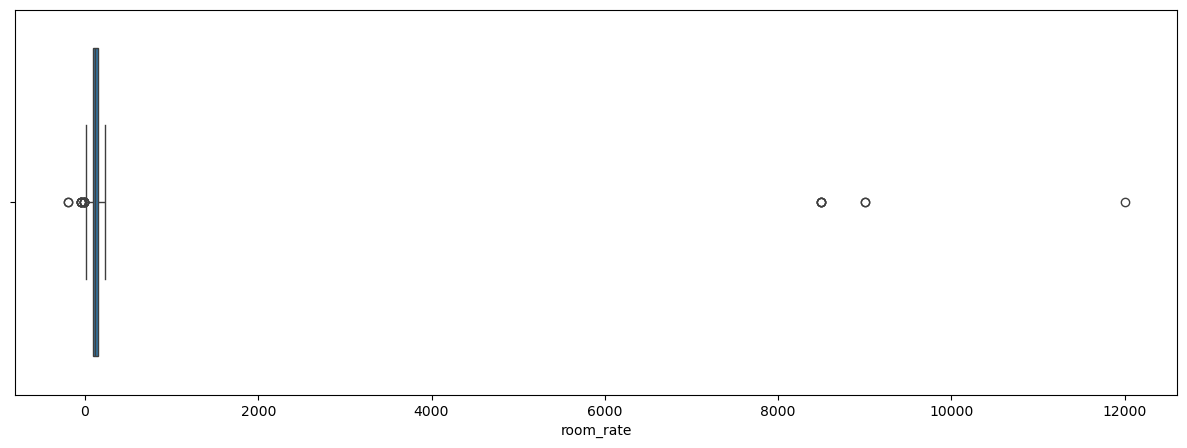

In [8]:
# YOUR CODE HERE
plt.figure(figsize = (15,5))

sns.boxplot(data = df, x = df['room_rate'])
plt.show()


### 4.2 The IQR Method – Detecting Outliers

**Formula:**
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Any value outside these bounds is flagged as an outlier.

In [26]:
# YOUR CODE HERE
# Compute IQR bounds AND print how many outliers were detected

Q1 = df['room_rate'].quantile(0.25)
Q2 = df['room_rate'].quantile(0.50)
Q3 = df['room_rate'].quantile(0.75)

IQR = Q3 - Q1 
 
LI = Q1-1.5*IQR 
LS = Q3+1.5*IQR

df[(df['room_rate'] > LS) | (df['room_rate'] < LI)]


,reservation_id,nights,room_type,room_rate,guests,lead_days,booking_channel,meal_plan,satisfaction,cancelled
22,0,0,0,0.0,0,0.0,0,0,0,0
69,0,0,0,0.0,0,0.0,0,0,0,0
82,0,0,0,0.0,0,0.0,0,0,0,0
85,0,0,0,0.0,0,0.0,0,0,0,0
104,0,0,0,0.0,0,0.0,0,0,0,0
145,0,0,0,0.0,0,0.0,0,0,0,0
146,0,0,0,0.0,0,0.0,0,0,0,0
177,0,0,0,0.0,0,0.0,0,0,0,0
184,RES-0185,7,TWIN,9000.0,3,352.0,ONLINE,NaN,Satisfied,0
188,0,0,0,0.0,0,0.0,0,0,0,0


### 4.3 Winsorization – Capping Outliers

Instead of removing outliers, **cap them** at the 5th and 95th percentile so the record stays in the dataset.


In [29]:
# YOUR CODE HERE

df['room_rate'] = df['room_rate'].clip(
    lower = df['room_rate'].quantile(0.05), 
    upper = df['room_rate'].quantile(0.95)
)

### 4.4 Log Transformation

Log transformation compresses large values, making skewed distributions more symmetric.

In [31]:
# YOUR CODE HERE

df['guests'] = np.log10(df['guests'])

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


> **Question:** What happened to the distribution shape after log transformation? Is it more symmetric? Why does this matter for machine learning models?

---

## Section 5 – Imputation (Handling Missing Values)

### 5.1 Simple Imputation – Mean & Median

- Fill missing values in `nights` using the **median** (robust to outliers).
- Fill missing values in `room_rate_wins` using the **mean**.
- Fill missing values in `lead_days` using the **median**.

Verify that no missing values remain in those columns.

In [ ]:
# YOUR CODE HERE

mean_nights = df['nights'].median()
mean_room_rate_


---

## Section 6 – Feature Encoding & Scaling

### 6.1 Label Encoding vs One-Hot Encoding vs Ordinal Encoding

| Technique | When to use |
|-----------|-------------|
| **Label Encoding** | Tree-based models, or binary columns |
| **One-Hot Encoding** | Nominal variables with algorithms sensitive to distances |
| **Ordinal Encoding** | Ordinal variables – you explicitly define the order |

#### One-Hot Encode `room_type` and `booking_channel`

In [ ]:
# YOUR CODE HERE



#### Ordinal Encode `satisfaction`

The satisfaction column is **ordinal** — it has a natural order:

`Very Dissatisfied < Dissatisfied < Neutral < Satisfied < Very Satisfied`

Encode it as integers 1–5.

In [ ]:
# YOUR CODE HERE
# Define the order and map to integers

satisfaction_order = [
    'Very Dissatisfied',
    'Dissatisfied',
    'Neutral',
    'Satisfied',
    'Very Satisfied'
]



### 6.2 Normalization vs Standardization

| Method | Formula | Output range | Use when |
|--------|---------|----------|----------|
| Min-Max (Normalization) | (x − min) / (max − min) | [0, 1] | KNN, Neural Networks |
| Z-score (Standardization) | (x − mean) / std | Any (centered at 0) | Linear regression, PCA, SVM |

Apply **Min-Max Normalization** to `lead_days` and **Z-score Standardization** to `room_rate_wins`. Store results in new columns.

In [ ]:
# YOUR CODE HERE
# Use sklearn's MinMaxScaler and StandardScaler



---

## Bonus – Correlation Analysis

Use a Pearson correlation heatmap to explore relationships between numerical features:
`nights`, `room_rate_wins`, `guests`, `lead_days`, `cancelled`.

In [ ]:
# YOUR CODE HERE
# Compute and plot a correlation matrix using seaborn heatmap



> **Discussion questions:**
> 1. Which pair of variables has the strongest correlation? Does this make business sense for a hotel?
> 2. Is there any relationship between `lead_days` and `cancelled`? What might explain it?
> 3. Would you expect `guests` and `nights` to be correlated? What do the data say?